# Split data

In [1]:
!ls

ASOC-D-26-01105.pdf  models		       README.MD
create_data.ipynb    mut_dict		       requirements.txt
data		     process_split_data.ipynb  update_scenarios.docx
install.sh	     __pycache__	       utils.py


# Omics Data

In [2]:
import os
import csv
from pubchempy import *
import numpy as np
import numbers
import h5py
import math
import pandas as pd
import json,pickle
from collections import OrderedDict
import rdkit
from rdkit import Chem
from rdkit.Chem import MolFromSmiles
import networkx as nx
from utils import *
import random
import pickle
import sys
import matplotlib.pyplot as plt
import argparse
import pickle
from tqdm.notebook import tqdm
import pandas as pd
from ipywidgets import IntProgress
data_split_path = "data/split_data/"
root = "data"

In [3]:
ge = pd.read_csv("data/ge_expression.csv")

In [4]:

def is_not_float(string_list):
    try:
        for string in string_list:
            float(string)
        return False
    except:
        return True

"""
The following 4 function is used to preprocess the drug data. We download the drug list manually, and download the SMILES format using pubchempy. Since this part is time consuming, I write the cids and SMILES into a csv file.
"""
def load_drug_list():
    filename = "data/gdsc/Druglist.csv"
    csvfile = open(filename, "rb")
    reader = csv.reader(csvfile)
    next(reader, None)
    drugs = []
    for line in reader:
        drugs.append(line[0])
    drugs = list(set(drugs))
    return drugs
def atom_features(atom):
    return np.array(one_of_k_encoding_unk(atom.GetSymbol(),['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na','Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb','Sb', 'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H','Li', 'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr','Cr', 'Pt', 'Hg', 'Pb', 'Unknown']) +
                    one_of_k_encoding(atom.GetDegree(), [0, 1, 2, 3, 4, 5, 6,7,8,9,10]) +
                    one_of_k_encoding_unk(atom.GetTotalNumHs(), [0, 1, 2, 3, 4, 5, 6,7,8,9,10]) +
                    one_of_k_encoding_unk(atom.GetValence(Chem.ValenceType.IMPLICIT), [0, 1, 2, 3, 4, 5, 6,7,8,9,10]) +
                    [atom.GetIsAromatic()])

def one_of_k_encoding(x, allowable_set):
    if x not in allowable_set:
        raise Exception("input {0} not in allowable set{1}:".format(x, allowable_set))
    return list(map(lambda s: x == s, allowable_set))

def one_of_k_encoding_unk(x, allowable_set):
    """Maps inputs not in the allowable set to the last element."""
    if x not in allowable_set:
        x = allowable_set[-1]
    return list(map(lambda s: x == s, allowable_set))

def smile_to_graph(smile):
    mol = Chem.MolFromSmiles(smile)

    c_size = mol.GetNumAtoms()

    features = []
    for atom in mol.GetAtoms():
        feature = atom_features(atom)
        features.append( feature / sum(feature) )

    edges = []
    for bond in mol.GetBonds():
        edges.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
    g = nx.Graph(edges).to_directed()
    edge_index = []
    for e1, e2 in g.edges:
        edge_index.append([e1, e2])

    return c_size, features, edge_index

def load_drug_smile():
    reader = csv.reader(open("data/smiles.csv"))
    next(reader, None)

    drug_dict = {}
    drug_smile = []

    for item in reader:
        name = item[0]
        smile = item[1]

        if name in drug_dict:
            pos = drug_dict[name]
        else:
            pos = len(drug_dict)
            drug_dict[name] = pos
        drug_smile.append(smile)

    smile_graph = {}
    for smile in drug_smile:
        g = smile_to_graph(smile)
        smile_graph[smile] = g

    return drug_dict, drug_smile, smile_graph
def save_cell_oge_matrix():
    m, n = ge.shape
    feature_names = list(ge.columns[1:])
    cell_dict = {}
    cell_names = []
    for i in tqdm(range(m)):
      cell_name = ge.iloc[i, 0]
      cell_names.append(cell_name)
      cell_feature = np.asarray(ge.iloc[i, 1:], dtype=float)
      cell_dict[cell_name] = cell_feature
    return cell_dict

def save_cell_meth_matrix():
    f = open("data/gdsc/METH_CELLLINES_BEMs_PANCAN.csv")
    reader = csv.reader(f)
    firstRow = next(reader)
    numberCol = len(firstRow) - 1
    features = {}
    cell_dict = {}
    matrix_list = []
    for item in reader:
        cell_id = int(item[0])
        meth = []
        for i in range(1, len(item)):
            meth.append(int(item[i]))
        cell_dict[cell_id] = np.asarray(meth)
    return cell_dict

"""
This part is used to read PANCANCER Gene Expression Cell line features
"""

def save_cell_mut_matrix():
    f = open("data/gdsc/PANCANCER_Genetic_feature.csv")
    reader = csv.reader(f)
    next(reader)
    features = {}
    cell_dict = {}
    mut_dict = {}
    matrix_list = []

    for item in reader:
        cell_id = int(item[1])
        mut = item[5]
        is_mutated = int(item[6])

        if mut in mut_dict:
            col = mut_dict[mut]
        else:
            col = len(mut_dict)
            mut_dict[mut] = col

        if cell_id in cell_dict:
            row = cell_dict[cell_id]
        else:
            row = len(cell_dict)
            cell_dict[cell_id] = row
        if is_mutated == 1:
            matrix_list.append((row, col))

    cell_feature = np.zeros((len(cell_dict), len(mut_dict)))

    for item in matrix_list:
        cell_feature[item[0], item[1]] = 1

    with open('mut_dict', 'wb') as fp:
        pickle.dump(mut_dict, fp)

    return cell_dict, cell_feature

"""
This part is used to read PANCANCER Meth Cell line features
"""


cell_dict_mut, cell_feature_mut = save_cell_mut_matrix()
cell_dict_meth = save_cell_meth_matrix()
cell_dict_ge = save_cell_oge_matrix()
drug_dict, drug_smile, smile_graph = load_drug_smile()

  0%|          | 0/1018 [00:00<?, ?it/s]

In [5]:
cell_gdsc_omics = list(set(cell_dict_ge.keys()).intersection(set(cell_dict_mut.keys())).intersection(set(cell_dict_meth.keys())))

In [6]:
len(cell_gdsc_omics)

765

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import tqdm
from collections import defaultdict

In [8]:
cells = pd.read_csv("data/cell_final.csv")
cells

,Cell ID,Cell line_Oneil
0,906792,A2058
1,906804,A2780
2,906793,A375
3,910851,A427
4,906825,Caov-3
5,1240128,ES2
6,905936,HCT116
7,907067,HT144
8,905939,HT-29
9,907788,LNCAP


In [9]:
ic_50 = pd.read_csv("data/ic_50_datn.csv")

In [10]:
ic_50

,Unnamed: 0,Drug name,Drug Id,Cell line name,Cosmic sample Id,TCGA classification,Tissue,Tissue sub-type,IC Result ID,IC50,AUC,Max conc,RMSE,Z score,Dataset version
0,0,Erlotinib,1,MC-CAR,683665,MM,blood,haematopoietic_neoplasm_other,112389,2.436586,0.982484,2.0,0.021894,-0.013193,17
1,1,Erlotinib,1,ES3,684055,UNCLASSIFIED,bone,ewings_sarcoma,46076,3.342826,0.984986,2.0,0.030357,0.777474,17
2,2,Erlotinib,1,ES5,684057,UNCLASSIFIED,bone,ewings_sarcoma,46573,3.571787,0.982939,2.0,0.031807,0.977236,17
3,3,Erlotinib,1,ES7,684059,UNCLASSIFIED,bone,ewings_sarcoma,47103,3.185231,0.984292,2.0,0.094084,0.639977,17
4,4,Erlotinib,1,EW-11,684062,UNCLASSIFIED,bone,ewings_sarcoma,49007,2.462555,0.946649,2.0,0.087727,0.009464,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179645,191822,Pevonedistat,1529,SNU-1040,1659823,COREAD,digestive_system,large_intestine,198372,1.379501,0.926174,1.0,0.034162,0.772169,17
179646,191823,Pevonedistat,1529,SNU-407,1660034,COREAD,digestive_system,large_intestine,199227,-0.278601,0.827363,1.0,0.051694,-0.318022,17
179647,191824,Pevonedistat,1529,SNU-61,1660035,COREAD,digestive_system,large_intestine,199956,3.013436,0.976436,1.0,0.040406,1.846470,17
179648,191825,Pevonedistat,1529,SNU-81,1660036,COREAD,digestive_system,large_intestine,200136,0.577129,0.879707,1.0,0.098300,0.244615,17


In [11]:
loewe = pd.read_csv("data/drug_combination_final.csv")

In [12]:
loewe_cells = list(np.unique(loewe["Cell line"]))

In [13]:
synergy = pd.read_csv("data/labels_deepsynergy.csv").drop(columns=["Unnamed: 0", "fold"])\
                .rename(columns={"drug_a_name":"Drug1", "drug_b_name":"Drug2", "cell_line":"Cell line"})

In [14]:
np.unique(synergy["Cell line"])

array(['A2058', 'A2780', 'A375', 'A427', 'CAOV3', 'COLO320DM', 'DLD1',
       'EFM192B', 'ES2', 'HCT116', 'HT144', 'HT29', 'KPL1', 'LNCAP',
       'LOVO', 'MDAMB436', 'MSTO', 'NCIH1650', 'NCIH2122', 'NCIH23',
       'NCIH460', 'NCIH520', 'OCUBM', 'OV90', 'OVCAR3', 'PA1', 'RKO',
       'RPMI7951', 'SKMEL30', 'SKMES1', 'SKOV3', 'SW620', 'SW837', 'T47D',
       'UACC62', 'UWB1289', 'UWB1289BRCA1', 'VCAP', 'ZR751'], dtype=object)

In [15]:
change_name_cell = {
    "NCIH460":"NCI-H460",
    "SKOV3":"SK-OV-3",
    "SW620":"SW-620",
    "T47D":"T-47D"
}
m, n = synergy.shape
for i in range(m):
    if synergy.loc[i, "Cell line"] in change_name_cell.keys():
        synergy.loc[i, "Cell line"] = change_name_cell[synergy.loc[i, "Cell line"]]

In [16]:
synergy = synergy[synergy["Cell line"].isin(loewe_cells)]
synergy

,Drug1,Drug2,Cell line,synergy
0,5-FU,ABT-888,A2058,7.693530
1,5-FU,ABT-888,A2780,7.778053
2,5-FU,ABT-888,A375,-1.198505
3,5-FU,ABT-888,A427,2.595684
8,5-FU,ABT-888,ES2,1.498650
...,...,...,...,...
23045,ZOLINZA,TOPOTECAN,SW837,3.986551
23046,ZOLINZA,TOPOTECAN,T-47D,18.985100
23047,ZOLINZA,TOPOTECAN,UACC62,10.223066
23049,ZOLINZA,TOPOTECAN,UWB1289,12.190316


In [17]:
loewe = synergy.reset_index().drop(columns=["index"])
loewe

,Drug1,Drug2,Cell line,synergy
0,5-FU,ABT-888,A2058,7.693530
1,5-FU,ABT-888,A2780,7.778053
2,5-FU,ABT-888,A375,-1.198505
3,5-FU,ABT-888,A427,2.595684
4,5-FU,ABT-888,ES2,1.498650
...,...,...,...,...
18299,ZOLINZA,TOPOTECAN,SW837,3.986551
18300,ZOLINZA,TOPOTECAN,T-47D,18.985100
18301,ZOLINZA,TOPOTECAN,UACC62,10.223066
18302,ZOLINZA,TOPOTECAN,UWB1289,12.190316


In [18]:
loewe.drop_duplicates(keep="first")

,Drug1,Drug2,Cell line,synergy
0,5-FU,ABT-888,A2058,7.693530
1,5-FU,ABT-888,A2780,7.778053
2,5-FU,ABT-888,A375,-1.198505
3,5-FU,ABT-888,A427,2.595684
4,5-FU,ABT-888,ES2,1.498650
...,...,...,...,...
18299,ZOLINZA,TOPOTECAN,SW837,3.986551
18300,ZOLINZA,TOPOTECAN,T-47D,18.985100
18301,ZOLINZA,TOPOTECAN,UACC62,10.223066
18302,ZOLINZA,TOPOTECAN,UWB1289,12.190316


In [19]:
len(np.unique(loewe["Cell line"]))

31

In [20]:
drug_pairs = defaultdict(int)
drugs = defaultdict(int)
drug_origin_pairs = defaultdict(int)
m, n = loewe.shape
for i in tqdm(range(m)):
    drug_1 = loewe.loc[i, "Drug1"]
    drug_2 = loewe.loc[i, "Drug2"]
    if drug_1 > drug_2:
        drug_pairs[(drug_1, drug_2)] += 1
    else:
        drug_pairs[(drug_2, drug_1)] += 1
    drugs[drug_1] += 1
    drugs[drug_2] += 1
    drug_origin_pairs[(drug_1, drug_2)] += 1

  0%|          | 0/18304 [00:00<?, ?it/s]

In [21]:
temp = loewe.drop_duplicates(["Drug1", "Drug2"], keep="first").reset_index()
drug_pairs = defaultdict(int)
drugs = defaultdict(int)
drug_origin_pairs = defaultdict(int)
m, n = temp.shape
for i in tqdm(range(m)):
    drug_1 = temp.loc[i, "Drug1"]
    drug_2 = temp.loc[i, "Drug2"]
    if drug_1 > drug_2:
        drug_pairs[(drug_1, drug_2)] += 1
    else:
        drug_pairs[(drug_2, drug_1)] += 1
    drugs[drug_1] += 1
    drugs[drug_2] += 1
    drug_origin_pairs[(drug_1, drug_2)] += 1

  0%|          | 0/583 [00:00<?, ?it/s]

In [22]:
loewe.columns

Index(['Drug1', 'Drug2', 'Cell line', 'synergy'], dtype='object')

In [23]:
def argument_data(df):
    df_argumented = df.rename(columns={"Drug1":"Drug2", "Drug2":"Drug1"})
    df_argumented = df_argumented[['Drug1', 'Drug2', 'Cell line', 'Cosmic sample Id', 'synergy', "Tissue"]]
    df_argumented = pd.concat([df_argumented, df], ignore_index=True)
    return df_argumented

In [24]:
cosmic_sample_id = pd.Series(
    loewe["Cell line"].map(dict(zip(cells["Cell line_Oneil"], cells["Cell ID"]))),
    index=loewe.index,
).ffill()
loewe.loc[:, "Cosmic sample Id"] = pd.to_numeric(cosmic_sample_id, downcast="integer")


In [25]:
loewe = loewe[['Drug1', 'Drug2', 'Cell line', 'Cosmic sample Id', 'synergy']].copy()
loewe


,Drug1,Drug2,Cell line,Cosmic sample Id,synergy
0,5-FU,ABT-888,A2058,906792,7.693530
1,5-FU,ABT-888,A2780,906804,7.778053
2,5-FU,ABT-888,A375,906793,-1.198505
3,5-FU,ABT-888,A427,910851,2.595684
4,5-FU,ABT-888,ES2,1240128,1.498650
...,...,...,...,...,...
18299,ZOLINZA,TOPOTECAN,SW837,909755,3.986551
18300,ZOLINZA,TOPOTECAN,T-47D,905945,18.985100
18301,ZOLINZA,TOPOTECAN,UACC62,905976,10.223066
18302,ZOLINZA,TOPOTECAN,UWB1289,1480374,12.190316


In [26]:
tissue = pd.Series(
    loewe["Cosmic sample Id"].map(dict(zip(ic_50["Cosmic sample Id"], ic_50["Tissue"]))),
    index=loewe.index,
).ffill()
loewe.loc[:, "Tissue"] = tissue


In [27]:
loewe = loewe[loewe["Cosmic sample Id"].isin(cell_gdsc_omics)]

In [28]:
loewe = loewe.sample(frac=1)
loewe

,Drug1,Drug2,Cell line,Cosmic sample Id,synergy,Tissue
5985,GELDANAMYCIN,SORAFENIB,MDAMB436,1240172,-17.595252,breast
17496,VINORELBINE,PD325901,UWB1289,1480374,9.848371,urogenital_system
7735,LAPATINIB,MK-5108,VCAP,1299075,15.967015,urogenital_system
7076,L778123,MK-8669,LOVO,907790,29.338215,digestive_system
4965,ERLOTINIB,DINACICLIB,NCIH2122,722046,20.254456,lung
...,...,...,...,...,...,...
5256,ETOPOSIDE,ABT-888,SK-OV-3,905959,10.962854,urogenital_system
7531,LAPATINIB,DASATINIB,SKMES1,909728,63.111857,lung
222,5-FU,GELDANAMYCIN,HCT116,905936,2.916663,digestive_system
2350,CARBOPLATIN,MK-4827,NCIH2122,722046,6.434045,lung


In [29]:
cells = pd.read_csv("data/cell_final.csv")
cells.head()

,Cell ID,Cell line_Oneil
0,906792,A2058
1,906804,A2780
2,906793,A375
3,910851,A427
4,906825,Caov-3


In [30]:
ge_process = pd.read_csv("data/ge_expression.csv")
ge_process = ge_process.rename(columns={"Cosmic sample Id":"GENE_SYMBOLS"})
ge_process = ge_process.set_index("GENE_SYMBOLS")

In [31]:
#check distribution
from scipy.stats import ks_2samp

# MIX DATA

## split

In [32]:
train_test_p = 0
train_val_p = 0
while (train_test_p < 0.95) or (train_val_p < 0.95):
    train_dc, test_set = train_test_split(loewe, test_size=0.4)
    val_dc, test_dc = train_test_split(test_set, test_size=0.5)
    train_test_p = ks_2samp(train_dc['synergy'], test_dc['synergy'])[1]
    train_val_p = ks_2samp(train_dc['synergy'], val_dc['synergy'])[1]
#

In [33]:
print(train_dc.shape, val_dc.shape, test_dc.shape)
print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
print(ks_2samp(train_dc['synergy'], val_dc['synergy']))
print(ks_2samp(test_dc['synergy'], val_dc['synergy']))

(8833, 6) (2944, 6) (2945, 6)
KstestResult(statistic=np.float64(0.009680975243900353), pvalue=np.float64(0.9842373618311797), statistic_location=np.float64(14.4593635455), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.00957370520134476), pvalue=np.float64(0.9860250443188645), statistic_location=np.float64(6.2117740304), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.01535902782903964), pvalue=np.float64(0.8706862363812898), statistic_location=np.float64(16.9612387156), statistic_sign=np.int8(1))


## check

KstestResult(statistic=np.float64(0.009680975243900353), pvalue=np.float64(0.9842373618311797), statistic_location=np.float64(14.4593635455), statistic_sign=np.int8(-1))


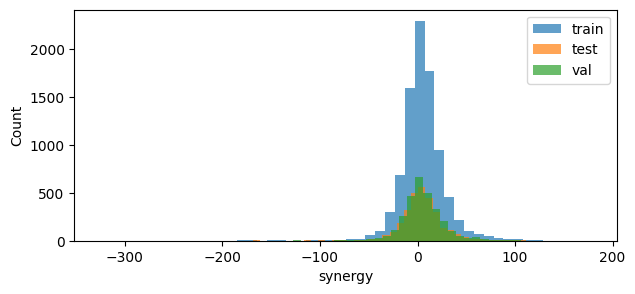

In [34]:
print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
plt.rcParams["figure.figsize"] = (7, 3)
kwargs = dict(histtype='stepfilled', alpha=0.7, bins=50)
plt.hist(train_dc['synergy'], **kwargs)
plt.hist(test_dc['synergy'], **kwargs)
plt.hist(val_dc['synergy'], **kwargs)
plt.legend(["train", "test", "val"])
plt.xlabel("synergy")
plt.ylabel("Count")
plt.show()

In [35]:
# argument
train_dc = argument_data(train_dc)
test_dc = argument_data(test_dc)
val_dc = argument_data(val_dc)

In [36]:
print(len(np.unique(train_dc["Drug1"])), len(np.unique(test_dc["Drug1"])), len(np.unique(val_dc["Drug1"])))
print(len(np.unique(train_dc["Tissue"])), len(np.unique(test_dc["Tissue"])), len(np.unique(val_dc["Tissue"])))
print(len(np.unique(train_dc["Cosmic sample Id"])), len(np.unique(test_dc["Cosmic sample Id"])), len(np.unique(val_dc["Cosmic sample Id"])))

38 38 38
5 5 5
25 25 25


## nor ge

In [37]:
ge_process_omics = ge_process.copy()

cell_train_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(train_dc["Cosmic sample Id"]))), dtype='int64')
cell_val_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(val_dc["Cosmic sample Id"]))), dtype='int64')
cell_test_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(test_dc["Cosmic sample Id"]))), dtype='int64')

cell_train = ge_process_omics.loc[cell_train_idx, :]
cell_val = ge_process_omics.loc[cell_val_idx, :]
cell_test = ge_process_omics.loc[cell_test_idx, :]

scaler = MinMaxScaler()
scaler.fit(cell_train[list(cell_train.columns)])

ge_process_omics[list(ge_process_omics.columns)] = scaler.transform(ge_process_omics[list(ge_process_omics.columns)])

## save

In [38]:
data_path = "data/split_data/mix_data/"
train_dc.to_csv(data_path + "train_dc.csv", index=False)
test_dc.to_csv(data_path + "test_dc.csv", index=False)
val_dc.to_csv(data_path + "val_dc.csv", index=False)
ge_process_omics.to_csv(data_path + "ge_process_new.csv", index=True, index_label="Cosmic sample Id")

# BLIND CELL

## split

In [39]:
list_drugs = np.unique(list(loewe["Drug1"]) + list(loewe["Drug2"]))
# list_cells = np.unique(loewe["Cell line"])

train_test_p = 0
train_val_p = 0
while (train_test_p < 0.9) or (train_val_p < 0.9):
#     train_cells , test_cells = train_test_split(list_cells, test_size=0.4)
    test_cells = []
    for t in np.unique(loewe["Tissue"]):
        cells = np.unique(loewe[loewe["Tissue"] == t]["Cell line"])
        train_temp, test_cell_temp = train_test_split(cells, test_size=0.2)
        test_cells += list(test_cell_temp)
    drug_mask = loewe["Drug1"].isin(list_drugs) & loewe["Drug2"].isin(list_drugs)
    train_dc = loewe[drug_mask & ~loewe["Cell line"].isin(test_cells)]

    blind_cell_set = loewe[drug_mask & loewe["Cell line"].isin(test_cells)]

    val_dc, test_dc = train_test_split(blind_cell_set, test_size=0.5)
    train_test_p = ks_2samp(train_dc['synergy'], test_dc['synergy'])[1]
    train_val_p = ks_2samp(train_dc['synergy'], val_dc['synergy'])[1]
    if (train_test_p> 0.9) or (train_val_p>0.9):
        print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
        print(ks_2samp(train_dc['synergy'], val_dc['synergy']))
        print(ks_2samp(test_dc['synergy'], val_dc['synergy']))
        print("______________________________________________")

print(blind_cell_set.shape)
print(train_dc.shape, val_dc.shape, test_dc.shape)


KstestResult(statistic=np.float64(0.009123264833475087), pvalue=np.float64(0.9970467663061754), statistic_location=np.float64(-5.3762083274), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.026832147186919952), pvalue=np.float64(0.1275121913617513), statistic_location=np.float64(17.104906457), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.025947887724868997), pvalue=np.float64(0.39711173803767275), statistic_location=np.float64(16.9117448875), statistic_sign=np.int8(-1))
______________________________________________
KstestResult(statistic=np.float64(0.012236321206288423), pvalue=np.float64(0.9330384562656096), statistic_location=np.float64(-6.0379847151), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.02600568163895744), pvalue=np.float64(0.14769828185525438), statistic_location=np.float64(1.2102741411), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.02478781382180013), pvalue=np.float64(0.45060586223788), statistic_loca

In [40]:
print(train_dc.shape, val_dc.shape, test_dc.shape)
print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
print(ks_2samp(train_dc['synergy'], val_dc['synergy']))
print(ks_2samp(test_dc['synergy'], val_dc['synergy']))

(10016, 6) (2353, 6) (2353, 6)
KstestResult(statistic=np.float64(0.012855292136067176), pvalue=np.float64(0.9071392760315433), statistic_location=np.float64(12.7081792159), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.012666601266278277), pvalue=np.float64(0.9160265276927717), statistic_location=np.float64(7.9493504023), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.013599660008499787), pvalue=np.float64(0.9815085595451105), statistic_location=np.float64(12.7565912479), statistic_sign=np.int8(1))


## check

In [41]:
print(len(np.unique(train_dc["Drug1"])), len(np.unique(test_dc["Drug1"])), len(np.unique(val_dc["Drug1"])))
print(len(np.unique(train_dc["Tissue"])), len(np.unique(test_dc["Tissue"])), len(np.unique(val_dc["Tissue"])))
print(len(np.unique(train_dc["Cosmic sample Id"])), len(np.unique(test_dc["Cosmic sample Id"])), len(np.unique(val_dc["Cosmic sample Id"])))

37 37 37
5 5 5
17 8 8


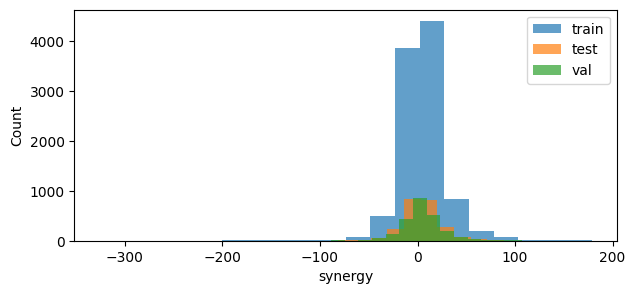

In [42]:
plt.rcParams["figure.figsize"] = (7, 3)
kwargs = dict(histtype='stepfilled', alpha=0.7, bins=20)
plt.hist(train_dc['synergy'], **kwargs)
plt.hist(test_dc['synergy'], **kwargs)
plt.hist(val_dc['synergy'], **kwargs)
plt.legend(["train", "test", "val"])
plt.xlabel("synergy")
plt.ylabel("Count")
plt.show()

## nor ge

In [43]:
ge_process_omics = ge_process.copy()

cell_train_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(train_dc["Cosmic sample Id"]))), dtype='int64')
cell_val_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(val_dc["Cosmic sample Id"]))), dtype='int64')
cell_test_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(test_dc["Cosmic sample Id"]))), dtype='int64')

cell_train = ge_process_omics.loc[cell_train_idx, :]
cell_val = ge_process_omics.loc[cell_val_idx, :]
cell_test = ge_process_omics.loc[cell_test_idx, :]

scaler = MinMaxScaler()
scaler.fit(cell_train[list(cell_train.columns)])

ge_process_omics[list(ge_process_omics.columns)] = scaler.transform(ge_process_omics[list(ge_process_omics.columns)])

In [44]:
# argument
train_dc = argument_data(train_dc)
test_dc = argument_data(test_dc)
val_dc = argument_data(val_dc)

In [45]:
test_dc.shape

(4706, 6)

## save

In [46]:
data_path = "data/split_data/blind_cell/"
train_dc.to_csv(data_path + "train_dc.csv", index=False)
test_dc.to_csv(data_path + "test_dc.csv", index=False)
val_dc.to_csv(data_path + "val_dc.csv", index=False)
ge_process_omics.to_csv(data_path + "ge_process.csv", index=True, index_label="Cosmic sample Id")

# Blind drug

## split

In [47]:
list_drugs = np.unique(list(loewe["Drug1"]) + list(loewe["Drug2"]))
list_cells = np.unique(loewe["Cell line"])
train_test_p = 0
train_val_p = 0
while (train_test_p < 0.85) or (train_val_p < 0.85):
    train_drugs, test_drugs = train_test_split(list_drugs, test_size=0.2)
    drug1_train_mask = loewe["Drug1"].isin(train_drugs)
    drug2_train_mask = loewe["Drug2"].isin(train_drugs)
    drug1_test_mask = loewe["Drug1"].isin(test_drugs)
    drug2_test_mask = loewe["Drug2"].isin(test_drugs)
    cell_mask = loewe["Cell line"].isin(list_cells)

    train_dc = loewe[drug1_train_mask & drug2_train_mask & cell_mask]

    #blind 1 drug
    blind_1_drug_set = pd.concat([
        loewe[drug1_train_mask & ~drug2_train_mask & cell_mask],
        loewe[~drug1_train_mask & drug2_train_mask & cell_mask],
    ], ignore_index=True)
    #blind 2 drug
    blind_2_drug_set = loewe[drug1_test_mask & drug2_test_mask & cell_mask]

    blind_drug_set = pd.concat([blind_1_drug_set, blind_2_drug_set], ignore_index=True)

    val_dc, test_dc = train_test_split(blind_drug_set, test_size=0.5)
    train_test_p = ks_2samp(train_dc['synergy'], test_dc['synergy'])[1]
    train_val_p = ks_2samp(train_dc['synergy'], val_dc['synergy'])[1]
    if (train_test_p > 0.85) or (train_val_p > 0.85):
        print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
        print(ks_2samp(train_dc['synergy'], val_dc['synergy']))
        print(ks_2samp(test_dc['synergy'], val_dc['synergy']))
        print("______________________________________________")


print(train_dc.shape, val_dc.shape, test_dc.shape)


KstestResult(statistic=np.float64(0.012450973824285314), pvalue=np.float64(0.8712210502908267), statistic_location=np.float64(11.6151275707), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.019751001839242867), pvalue=np.float64(0.3387778688335003), statistic_location=np.float64(13.9196011195), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.02730263157894737), pvalue=np.float64(0.20721615536280266), statistic_location=np.float64(13.7587341825), statistic_sign=np.int8(1))
______________________________________________
KstestResult(statistic=np.float64(0.012499507081888933), pvalue=np.float64(0.9062162481606135), statistic_location=np.float64(47.612844831), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.010595047230489082), pvalue=np.float64(0.9752803127734396), statistic_location=np.float64(-25.1744282286), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.016279650613380457), pvalue=np.float64(0.8792335506634432), statistic

In [48]:
print(train_dc.shape, val_dc.shape, test_dc.shape)

(9619, 6) (2551, 6) (2552, 6)


In [49]:
print(train_dc.shape, val_dc.shape, test_dc.shape)
print(ks_2samp(train_dc['synergy'], test_dc['synergy']))
print(ks_2samp(train_dc['synergy'], val_dc['synergy']))
print(ks_2samp(test_dc['synergy'], val_dc['synergy']))

(9619, 6) (2551, 6) (2552, 6)
KstestResult(statistic=np.float64(0.012499507081888933), pvalue=np.float64(0.9062162481606135), statistic_location=np.float64(47.612844831), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.010595047230489082), pvalue=np.float64(0.9752803127734396), statistic_location=np.float64(-25.1744282286), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.016279650613380457), pvalue=np.float64(0.8792335506634432), statistic_location=np.float64(2.6175086922), statistic_sign=np.int8(1))


## check

In [50]:
print(len(np.unique(train_dc["Drug1"])), len(np.unique(test_dc["Drug1"])), len(np.unique(val_dc["Drug1"])))
print(len(np.unique(train_dc["Tissue"])), len(np.unique(test_dc["Tissue"])), len(np.unique(val_dc["Tissue"])))
print(len(np.unique(train_dc["Cosmic sample Id"])), len(np.unique(test_dc["Cosmic sample Id"])), len(np.unique(val_dc["Cosmic sample Id"])))

29 26 26
5 5 5
25 25 25


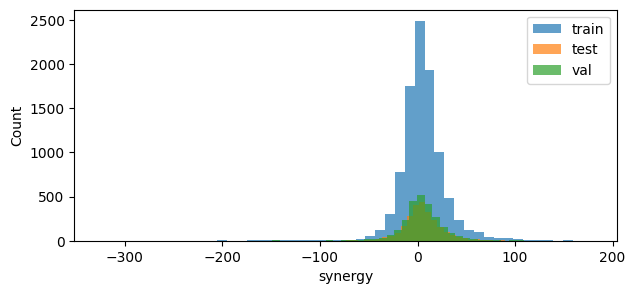

In [51]:
plt.rcParams["figure.figsize"] = (7, 3)
kwargs = dict(histtype='stepfilled', alpha=0.7, bins=50)
plt.hist(train_dc['synergy'], **kwargs)
plt.hist(test_dc['synergy'], **kwargs)
plt.hist(val_dc['synergy'], **kwargs)
plt.legend(["train", "test", "val"])
plt.xlabel("synergy")
plt.ylabel("Count")
plt.show()

## nor ge

In [52]:
len(np.unique(test_dc["Drug1"]))

26

In [53]:
ge_process_omics = ge_process.copy()
cell_train_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(train_dc["Cosmic sample Id"]))), dtype='int64')
cell_val_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(val_dc["Cosmic sample Id"]))), dtype='int64')
cell_test_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(test_dc["Cosmic sample Id"]))), dtype='int64')

cell_train = ge_process_omics.loc[cell_train_idx, :]
cell_val = ge_process_omics.loc[cell_val_idx, :]
cell_test = ge_process_omics.loc[cell_test_idx, :]

scaler = MinMaxScaler()
scaler.fit(cell_train[list(cell_train.columns)])

ge_process_omics[list(ge_process_omics.columns)] = scaler.transform(ge_process_omics[list(ge_process_omics.columns)])

In [54]:
# argument
train_dc = argument_data(train_dc)
test_dc = argument_data(test_dc)
val_dc = argument_data(val_dc)

## save

In [55]:
data_path = "data/split_data/blind_drug/"
train_dc.to_csv(data_path + "train_dc.csv", index=False)
test_dc.to_csv(data_path + "test_dc.csv", index=False)
val_dc.to_csv(data_path + "val_dc.csv", index=False)
ge_process_omics.to_csv(data_path + "ge_process_new.csv", index=True, index_label="Cosmic sample Id")

# ALL TEST

In [56]:
import pandas as pd
import numpy as np

test_drugs = list(set(np.unique(pd.read_csv("data/split_data/blind_drug/test_dc.csv")["Drug1"])) - set(np.unique(pd.read_csv("data/split_data/blind_drug/train_dc.csv")["Drug1"])))
train_drugs = np.unique(pd.read_csv("data/split_data/blind_drug/train_dc.csv")["Drug1"])

test_cells = np.unique(pd.read_csv("data/split_data/blind_cell/test_dc.csv")["Cell line"])
train_cells = np.unique(pd.read_csv("data/split_data/blind_cell/train_dc.csv")["Cell line"])
print(len(test_cells), len(train_cells))
print(len(test_drugs), len(train_drugs))

8 17
8 30


In [57]:
# train_drugs, test_drugs = train_test_split(list_drugs, test_size=0.15)
# train_cells , test_cells = train_test_split(list_cells, test_size=0.15)

In [58]:
loewe[loewe["Cell line"].isin(test_cells)].drop_duplicates(["Cell line"])

,Drug1,Drug2,Cell line,Cosmic sample Id,synergy,Tissue
5985,GELDANAMYCIN,SORAFENIB,MDAMB436,1240172,-17.595252,breast
7076,L778123,MK-8669,LOVO,907790,29.338215,digestive_system
10911,MK-4541,MK-2206,NCIH1650,687800,16.142914,lung
2004,CARBOPLATIN,ABT-888,LNCAP,907788,-27.490414,urogenital_system
17516,VINORELBINE,SORAFENIB,OVCAR3,905933,-44.253774,urogenital_system
4199,DINACICLIB,MK-8776,RPMI7951,910903,-14.747843,skin
6962,L778123,LAPATINIB,SKMES1,909728,17.807070,lung
13663,MRK-003,TEMOZOLOMIDE,SKMEL30,909726,22.102862,skin


In [59]:
test_cells

array(['LNCAP', 'LOVO', 'MDAMB436', 'NCIH1650', 'OVCAR3', 'RPMI7951',
       'SKMEL30', 'SKMES1'], dtype=object)

In [60]:
#train set
drug1_train_mask = loewe["Drug1"].isin(train_drugs)
drug2_train_mask = loewe["Drug2"].isin(train_drugs)
train_cell_mask = loewe["Cell line"].isin(train_cells)
train_set = loewe[drug1_train_mask & drug2_train_mask & train_cell_mask]


In [61]:
#blind cell
drug1_train_mask = loewe["Drug1"].isin(train_drugs)
drug2_train_mask = loewe["Drug2"].isin(train_drugs)
test_cell_mask = loewe["Cell line"].isin(test_cells)
blind_cell_set = loewe[drug1_train_mask & drug2_train_mask & test_cell_mask]
print(blind_cell_set.shape)


(3074, 6)


In [62]:
#blind 1 drug
drug1_train_mask = loewe["Drug1"].isin(train_drugs)
drug2_train_mask = loewe["Drug2"].isin(train_drugs)
train_cell_mask = loewe["Cell line"].isin(train_cells)
blind_1_drug_set = pd.concat([
    loewe[drug1_train_mask & ~drug2_train_mask & train_cell_mask],
    loewe[~drug1_train_mask & drug2_train_mask & train_cell_mask],
]).reset_index(drop=True)
print(blind_1_drug_set.shape)


(3165, 6)


In [63]:
#blind 1 drug and cell
drug1_train_mask = loewe["Drug1"].isin(train_drugs)
drug2_train_mask = loewe["Drug2"].isin(train_drugs)
test_cell_mask = loewe["Cell line"].isin(test_cells)
blind_1_drug_cell_set = pd.concat([
    loewe[drug1_train_mask & ~drug2_train_mask & test_cell_mask],
    loewe[~drug1_train_mask & drug2_train_mask & test_cell_mask],
], ignore_index=True)
print(blind_1_drug_cell_set.shape)


(1488, 6)


In [64]:
#blind 2 drug
drug1_test_mask = loewe["Drug1"].isin(test_drugs)
drug2_test_mask = loewe["Drug2"].isin(test_drugs)
train_cell_mask = loewe["Cell line"].isin(train_cells)
blind_2_drug_set = loewe[drug1_test_mask & drug2_test_mask & train_cell_mask]
print(blind_2_drug_set.shape)


(306, 6)


In [65]:
#blind all
drug1_test_mask = loewe["Drug1"].isin(test_drugs)
drug2_test_mask = loewe["Drug2"].isin(test_drugs)
test_cell_mask = loewe["Cell line"].isin(test_cells)
blind_all_set = loewe[drug1_test_mask & drug2_test_mask & test_cell_mask]
print(blind_all_set.shape)


(144, 6)


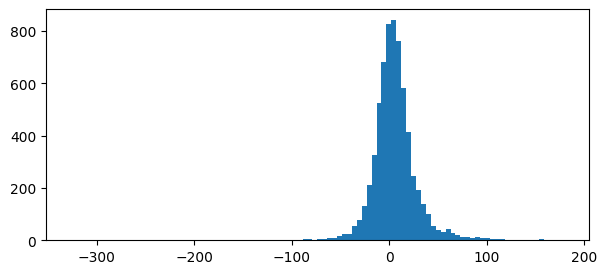

In [66]:
plt.hist(train_set["synergy"], bins=100)
plt.show()

In [67]:
train_dc, mix_set = train_test_split(train_set, test_size=0.2)

In [68]:
mix_val, mix_test = train_test_split(mix_set, test_size=0.5)
blind_cell_val, blind_cell_test = train_test_split(blind_cell_set, test_size=0.5)
blind_1_drug_val, blind_1_drug_test = train_test_split(blind_1_drug_set, test_size=0.5)
blind_1_drug_cell_val, blind_1_drug_cell_test = train_test_split(blind_1_drug_cell_set, test_size=0.5)
blind_2_drug_val, blind_2_drug_test = train_test_split(blind_2_drug_set, test_size=0.5)
blind_all_val, blind_all_test = train_test_split(blind_all_set, test_size=0.5)

In [69]:
print(len(np.unique(mix_val["Drug1"])), len(np.unique(mix_val["Drug2"])), len(np.unique(mix_val["Cell line"])))
print(len(np.unique(mix_set["Drug1"])), len(np.unique(mix_set["Drug2"])), len(np.unique(mix_set["Cell line"])))

29 27 17
29 29 17


In [70]:
print(len(np.unique(train_dc["Drug1"])), len(np.unique(train_dc["Drug2"])), len(np.unique(train_dc["Cell line"])))

29 29 17


In [71]:
print(set(np.unique(blind_cell_val["Drug1"]))-set(train_drugs))
print(set(np.unique(blind_cell_val["Drug2"]))-set(train_drugs))
print(set(np.unique(blind_cell_val["Cell line"])).intersection(set(train_cells)))
print("___")
print(set(np.unique(blind_cell_test["Drug1"]))-set(train_drugs))
print(set(np.unique(blind_cell_test["Drug2"]))-set(train_drugs))
print(set(np.unique(blind_cell_test["Cell line"])).intersection(set(train_cells)))

set()
set()
set()
___
set()
set()
set()


In [72]:
train_dc = train_dc
val_dc = pd.concat([mix_val, blind_cell_val, blind_1_drug_val, blind_1_drug_cell_val, blind_2_drug_val, blind_all_val])
test_dc = pd.concat([mix_test, blind_cell_test, blind_1_drug_test, blind_1_drug_cell_test, blind_2_drug_test, blind_all_test])

In [73]:
train_dc = argument_data(train_dc)
test_dc = argument_data(test_dc)
val_dc = argument_data(val_dc)

mix_val = argument_data(mix_val)
mix_test = argument_data(mix_test)

blind_cell_val = argument_data(blind_cell_val)
blind_cell_test = argument_data(blind_cell_test)

blind_1_drug_val = argument_data(blind_1_drug_val)
blind_1_drug_test = argument_data(blind_1_drug_test)

blind_1_drug_cell_val = argument_data(blind_1_drug_cell_val)
blind_1_drug_cell_test = argument_data(blind_1_drug_cell_test)

blind_2_drug_val = argument_data(blind_2_drug_val)
blind_2_drug_test = argument_data(blind_2_drug_test)

blind_all_val = argument_data(blind_all_val)
blind_all_test = argument_data(blind_all_test)

In [74]:
print(train_dc.shape[0] + test_dc.shape[0] + val_dc.shape[0])

29444


In [75]:
print(len(np.unique(test_dc["Cell line"])), len(np.unique(val_dc["Cell line"])), len(np.unique(train_dc["Cell line"])))

25 25 17


In [76]:
cells = pd.read_csv("data/cell_final.csv")
cells.head()
ge_process = pd.read_csv("data/gdsc/ge_expression.csv")
ge_process = ge_process.rename(columns={"Cosmic sample Id":"GENE_SYMBOLS"})
ge_process = ge_process.set_index("GENE_SYMBOLS")

# GE

In [77]:
ge_process

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,LINC00526,PPY2,Unnamed: 17730,Unnamed: 17731,KRT18P55,Unnamed: 17733,POLRMTP1,UBL5P2,TBC1D3P5,Unnamed: 17737
GENE_SYMBOLS,,,,,,,,,,,,,,,,,,,,,
906826,0.798294,0.542935,0.721936,0.042346,0.289824,0.453452,0.272563,0.772089,0.243580,0.776778,...,1.156007,0.231674,0.066878,-0.042313,0.484833,0.253580,0.248354,1.280923,-0.001263,0.487426
687983,0.769161,0.091755,1.469616,0.414517,0.568452,0.211750,2.348012,0.397538,0.483803,2.151788,...,0.737880,0.666273,0.044123,0.336160,-0.026218,0.183613,0.344198,0.525121,-0.091709,0.952238
910927,1.175881,-0.232280,0.460723,0.323422,0.175727,0.336386,-0.036900,0.768955,0.323797,0.591295,...,0.118835,0.419226,-0.014251,0.348753,-0.186298,0.099150,0.281857,0.609958,-0.194904,0.401464
1240138,0.856006,0.188832,0.462157,0.411895,0.430588,0.139980,2.048218,0.872622,0.403659,0.498428,...,0.121934,0.483483,-0.050192,-0.046975,1.210952,0.792766,0.206964,1.259157,0.223526,0.500148
1240139,0.832283,0.526407,0.742510,0.640584,0.653900,0.000469,0.179562,0.793894,0.425291,-0.111326,...,0.263898,0.103621,-0.050729,0.461532,0.607797,0.344756,0.309302,1.244325,0.395246,0.655866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298157,1.081264,-0.242496,1.289686,0.710022,1.085033,0.319923,0.274927,0.769369,0.426205,0.459255,...,0.675253,0.404289,0.127335,0.065717,0.503838,0.351903,0.157728,0.778165,0.443562,1.671220
1480372,1.074726,0.338445,0.815266,-0.010673,0.976098,0.245323,0.153448,0.936573,0.013349,-0.084655,...,0.432055,0.292094,0.031343,0.563817,0.607755,0.366185,0.217564,1.861744,0.299094,0.075671
1298533,0.958104,-0.527657,0.938313,0.724418,0.044840,0.332260,1.072929,0.741149,0.414578,0.531685,...,0.671542,0.206929,0.335294,0.237771,0.951701,0.301006,0.040028,0.173173,0.122696,0.424368


In [78]:
print(np.unique(blind_cell_set["Cell line"]))
print(np.unique(blind_cell_set["Tissue"]))
print(np.unique(train_dc["Tissue"], return_counts=True))

['LNCAP' 'LOVO' 'MDAMB436' 'NCIH1650' 'OVCAR3' 'RPMI7951' 'SKMEL30'
 'SKMES1']
['breast' 'digestive_system' 'lung' 'skin' 'urogenital_system']
(array(['breast', 'digestive_system', 'lung', 'skin', 'urogenital_system'],
      dtype=object), array([1196, 1858, 2488, 2492, 2438]))


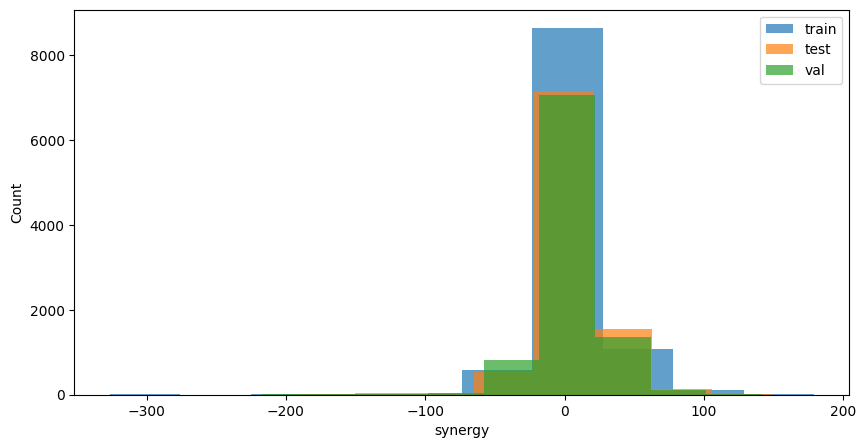

In [79]:
plt.rcParams["figure.figsize"] = (10, 5)
kwargs = dict(histtype='stepfilled', alpha=0.7, bins=10)
plt.hist(train_dc['synergy'], **kwargs)
plt.hist(test_dc['synergy'], **kwargs)
plt.hist(val_dc['synergy'], **kwargs)
plt.legend(["train", "test", "val"])
plt.xlabel("synergy")
plt.ylabel("Count")
plt.show()

In [80]:
print(train_dc.shape, val_dc.shape, test_dc.shape)

(10472, 6) (9484, 6) (9488, 6)


In [81]:
print(len(np.unique(train_dc["Cosmic sample Id"])), len(np.unique(val_dc["Cosmic sample Id"])), len(np.unique(test_dc["Cosmic sample Id"])))

17 25 25


In [82]:
# set(ge_process.index).intersection(set(np.unique(train_dc["Cosmic sample Id"])))

In [83]:
cell_train_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(train_dc["Cosmic sample Id"]))), dtype='int64')
cell_val_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(val_dc["Cosmic sample Id"]))), dtype='int64')
cell_test_idx = pd.Index(set(ge_process.index).intersection(set(np.unique(test_dc["Cosmic sample Id"]))), dtype='int64')

cell_train = ge_process.loc[cell_train_idx, :]
cell_val = ge_process.loc[cell_val_idx, :]
cell_test = ge_process.loc[cell_test_idx, :]

scaler = MinMaxScaler()
scaler.fit(cell_train[list(cell_train.columns)])

ge_process[list(ge_process.columns)] = scaler.transform(ge_process[list(ge_process.columns)])

In [84]:
ge_process.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,LINC00526,PPY2,Unnamed: 17730,Unnamed: 17731,KRT18P55,Unnamed: 17733,POLRMTP1,UBL5P2,TBC1D3P5,Unnamed: 17737
GENE_SYMBOLS,,,,,,,,,,,,,,,,,,,,,
906826,0.765591,0.920181,0.721936,0.026371,0.289824,0.825187,0.166175,0.731297,0.067800,0.665695,...,1.402451,0.231674,0.066878,-0.050665,0.492750,0.316033,0.255936,1.094739,-0.171650,0.487426
687983,0.737651,0.290639,1.469616,0.258142,0.568452,0.369256,1.330556,0.376535,0.264517,1.844070,...,0.895185,0.666273,0.044123,0.330840,-0.010447,0.228834,0.350813,0.516111,-0.353240,0.952238
910927,1.127709,-0.161495,0.460723,0.201412,0.175727,0.604361,-0.007442,0.728329,0.133489,0.506736,...,0.144168,0.419226,-0.014251,0.343535,-0.168067,0.123569,0.289101,0.581061,-0.560426,0.401464
1240138,0.820938,0.426091,0.462157,0.256509,0.430588,0.233875,1.162364,0.826518,0.198887,0.427150,...,0.147929,0.483483,-0.050192,-0.055365,1.207710,0.988011,0.214963,1.078075,0.279665,0.500148
1240139,0.798187,0.897118,0.742510,0.398925,0.653900,-0.029290,0.113998,0.751950,0.216602,-0.095406,...,0.320157,0.103621,-0.050729,0.457218,0.613824,0.429663,0.316268,1.066720,0.624432,0.655866


In [85]:
train_dc.to_csv("data/split_data/all_test/train_dc.csv", index=False)
test_dc.to_csv("data/split_data/all_test/test_dc.csv", index=False)
val_dc.to_csv("data/split_data/all_test/val_dc.csv", index=False)
ge_process.to_csv("data/split_data/all_test/ge_process.csv", index=True, index_label="Cosmic sample Id")
mix_val.to_csv("data/split_data/all_test/mix_val.csv", index=False)
mix_test.to_csv("data/split_data/all_test/mix_test.csv", index=False)

blind_cell_val.to_csv("data/split_data/all_test/blind_cell_val.csv", index=False)
blind_cell_test.to_csv("data/split_data/all_test/blind_cell_test.csv", index=False)

blind_1_drug_val.to_csv("data/split_data/all_test/blind_1_drug_val.csv", index=False)
blind_1_drug_test.to_csv("data/split_data/all_test/blind_1_drug_test.csv", index=False)

blind_1_drug_cell_val.to_csv("data/split_data/all_test/blind_1_drug_cell_val.csv", index=False)
blind_1_drug_cell_test.to_csv("data/split_data/all_test/blind_1_drug_cell_test.csv", index=False)

blind_2_drug_val.to_csv("data/split_data/all_test/blind_2_drug_val.csv", index=False)
blind_2_drug_test.to_csv("data/split_data/all_test/blind_2_drug_test.csv", index=False)

blind_all_val.to_csv("data/split_data/all_test/blind_all_val.csv", index=False)
blind_all_test.to_csv("data/split_data/all_test/blind_all_test.csv", index=False)

In [86]:
ge_process.to_csv("data/split_data/all_test/ge_process.csv", index=True, index_label="Cosmic sample Id")

In [87]:
ge_process = pd.read_csv("data/split_data/all_test/ge_process.csv")

In [88]:
ge_process

,Cosmic sample Id,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,LINC00526,PPY2,Unnamed: 17730,Unnamed: 17731,KRT18P55,Unnamed: 17733,POLRMTP1,UBL5P2,TBC1D3P5,Unnamed: 17737
0,906826,0.765591,0.920181,0.721936,0.026371,0.289824,0.825187,0.166175,0.731297,0.067800,...,1.402451,0.231674,0.066878,-0.050665,0.492750,0.316033,0.255936,1.094739,-0.171650,0.487426
1,687983,0.737651,0.290639,1.469616,0.258142,0.568452,0.369256,1.330556,0.376535,0.264517,...,0.895185,0.666273,0.044123,0.330840,-0.010447,0.228834,0.350813,0.516111,-0.353240,0.952238
2,910927,1.127709,-0.161495,0.460723,0.201412,0.175727,0.604361,-0.007442,0.728329,0.133489,...,0.144168,0.419226,-0.014251,0.343535,-0.168067,0.123569,0.289101,0.581061,-0.560426,0.401464
3,1240138,0.820938,0.426091,0.462157,0.256509,0.430588,0.233875,1.162364,0.826518,0.198887,...,0.147929,0.483483,-0.050192,-0.055365,1.207710,0.988011,0.214963,1.078075,0.279665,0.500148
4,1240139,0.798187,0.897118,0.742510,0.398925,0.653900,-0.029290,0.113998,0.751950,0.216602,...,0.320157,0.103621,-0.050729,0.457218,0.613824,0.429663,0.316268,1.066720,0.624432,0.655866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,1298157,1.036968,-0.175751,1.289686,0.442168,1.085033,0.573307,0.167501,0.728721,0.217350,...,0.819207,0.404289,0.127335,0.058231,0.511463,0.438571,0.166223,0.709837,0.721436,1.671220
1014,1480372,1.030698,0.634851,0.815266,-0.006647,0.976098,0.432586,0.099348,0.887091,-0.120735,...,0.524162,0.292094,0.031343,0.560322,0.613783,0.456370,0.225456,1.539404,0.431386,0.075671
1015,1298533,0.918853,-0.573643,0.938313,0.451133,0.044840,0.596579,0.615201,0.701992,0.207829,...,0.814705,0.206929,0.335294,0.231664,0.952443,0.375139,0.049710,0.246667,0.077225,0.424368
1016,930299,-0.749397,0.603109,0.457146,0.360644,0.170640,0.039358,0.122668,0.185168,0.273080,...,0.780616,0.223679,0.067605,0.229253,0.212564,0.322270,0.039031,1.044118,0.247721,0.616015


In [89]:
train_dc

,Drug1,Drug2,Cell line,Cosmic sample Id,synergy,Tissue
0,METFORMIN,MRK-003,A375,906793,11.354423,skin
1,L778123,5-FU,NCIH2122,722046,1.491916,lung
2,BEZ-235,PACLITAXEL,OCUBM,909256,-5.602027,breast
3,MK-8669,AZD1775,HT144,907067,20.252393,skin
4,SORAFENIB,PACLITAXEL,HCT116,905936,-0.125242,digestive_system
...,...,...,...,...,...,...
10467,MK-5108,MK-2206,RKO,909698,4.540834,digestive_system
10468,MK-5108,SN-38,A375,906793,3.299311,skin
10469,MITOMYCINE,SUNITINIB,MSTO,908152,-2.668501,lung
10470,PACLITAXEL,DINACICLIB,OCUBM,909256,-7.768051,breast


In [90]:
np.unique(blind_cell_set["Cell line"])

array(['LNCAP', 'LOVO', 'MDAMB436', 'NCIH1650', 'OVCAR3', 'RPMI7951',
       'SKMEL30', 'SKMES1'], dtype=object)

In [91]:
def convert_to_cls(x):
    if x > 0:
        return 1
    return 0

In [92]:
data_list = [
    (train_dc, "train_dc"),
    (test_dc, "test_dc"),
    (val_dc, "val_dc"),
    (mix_val, "mix_val"),
    (mix_test, "mix_test"),
    (blind_cell_val, "blind_cell_val"),
    (blind_cell_test, "blind_cell_test"),
    (blind_1_drug_val, "blind_1_drug_val"),
    (blind_1_drug_test, "blind_1_drug_test"),
    (blind_1_drug_cell_val, "blind_1_drug_cell_val"),
    (blind_1_drug_cell_test, "blind_1_drug_cell_test"),
    (blind_2_drug_val, "blind_2_drug_val"),
    (blind_2_drug_test, "blind_2_drug_test"),
    (blind_all_val, "blind_all_val"),
    (blind_all_test, "blind_all_test"),
]
for data in data_list:
    data[0]["cls"] = data[0]["synergy"].apply(convert_to_cls)

In [93]:
for data in data_list:
    print(data[1], np.unique(data[0]["cls"], return_counts=True))

train_dc (array([0, 1]), array([4130, 6342]))
test_dc (array([0, 1]), array([3702, 5786]))
val_dc (array([0, 1]), array([3670, 5814]))
mix_val (array([0, 1]), array([526, 782]))
mix_test (array([0, 1]), array([496, 814]))
blind_cell_val (array([0, 1]), array([1100, 1974]))
blind_cell_test (array([0, 1]), array([1258, 1816]))
blind_1_drug_val (array([0, 1]), array([1274, 1890]))
blind_1_drug_test (array([0, 1]), array([1176, 1990]))
blind_1_drug_cell_val (array([0, 1]), array([622, 866]))
blind_1_drug_cell_test (array([0, 1]), array([606, 882]))
blind_2_drug_val (array([0, 1]), array([ 96, 210]))
blind_2_drug_test (array([0, 1]), array([112, 194]))
blind_all_val (array([0, 1]), array([52, 92]))
blind_all_test (array([0, 1]), array([54, 90]))


In [94]:
blind_all_test

,Drug1,Drug2,Cell line,Cosmic sample Id,synergy,Tissue,cls
0,ZOLINZA,VINBLASTINE,RPMI7951,910903,-11.507612,skin,0
1,ZOLINZA,ETOPOSIDE,SKMES1,909728,17.935186,lung,1
2,PD325901,CYCLOPHOSPHAMIDE,NCIH1650,687800,-4.553469,lung,0
3,ERLOTINIB,GEMCITABINE,MDAMB436,1240172,11.183867,breast,1
4,PD325901,CARBOPLATIN,OVCAR3,905933,-4.533271,urogenital_system,0
...,...,...,...,...,...,...,...
139,ZOLINZA,PD325901,MDAMB436,1240172,20.204690,breast,1
140,ETOPOSIDE,ZOLINZA,NCIH1650,687800,3.523127,lung,1
141,ETOPOSIDE,ZOLINZA,RPMI7951,910903,7.496752,skin,1
142,CARBOPLATIN,ERLOTINIB,SKMEL30,909726,-2.097137,skin,0


In [95]:
len(set(cell_dict_mut.keys()).intersection(set(np.unique(cells["Cell ID"]))))

33

In [96]:
len(set(cell_dict_meth.keys()).intersection(set(np.unique(blind_cell_test["Cosmic sample Id"]))))

8

In [97]:
len(set(cell_dict_ge.keys()).intersection(set(np.unique(cells["Cell ID"]))))

31

In [98]:
len(np.unique(test_dc["Drug1"]))

38

In [99]:
len(np.unique(synergy["Cell line"]))

31